# Customer Churn Prediction Using Machine Learning
**Internship Project — Final Consolidated Submission Notebook**  
**Student Name:** Subham Prasad Nayak  
**Project:** Telco Customer Churn Prediction  
**Track / Internship:** AICTE / IBM SkillsBuild Internship  
**Task Type:** Supervised Machine Learning — Binary Classification  

---

### Project Overview
Customer churn — the voluntary cancellation of a subscription or service — represents a major financial and operational risk for telecommunications providers. Because acquiring a new subscriber typically incurs substantial sales, marketing, and onboarding costs compared to retaining an existing customer, identifying churn risk proactively allows businesses to deploy targeted retention interventions.

This notebook consolidates the complete, reproducible end-to-end data science and machine learning workflow for customer churn prediction:
1. **Data Understanding:** Inspecting raw dimensions, column structures, data types, and initial records.
2. **Data Quality Audit:** Rigorous verification for duplicates, standard missing values, hidden whitespace strings, and identifier cardinality.
3. **Data Cleaning:** Documented data cleaning, type coercion, contextual imputation, and record deduplication.
4. **Exploratory Data Analysis (EDA):** Visualising target distribution, numerical features, contract patterns, tenure buckets, service subscriptions, billing methods, and correlation structure.
5. **Feature Engineering & Preprocessing:** Encapsulating standard scaling, median imputation, one-hot encoding, and frequent imputation into a leakage-free `ColumnTransformer` pipeline.
6. **Model Training:** Training four baseline classification models: Logistic Regression, Decision Tree, Random Forest, and Gradient Boosting.
7. **Model Evaluation:** Evaluating models on a held-out test set using Accuracy, Precision, Recall, F1-Score, ROC-AUC, confusion matrices, and ROC curves.
8. **Model Interpretation:** Analysing logistic regression coefficients and ensemble feature importances to understand predictive associations.
9. **Final Model Selection:** Multi-criteria, evidence-driven selection of Random Forest as the primary model.
10. **Model Serialisation:** Saving and verifying the complete production-ready pipeline artifact (`models/final_churn_model.joblib`).
11. **Inference Demonstration:** Applying the saved model to hypothetical new customer records across defined risk profiles.
12. **Conclusion & References:** Summarising business implications, methodological constraints, and literature citations.

---
## 2. Import Libraries and Configure Environment

We import the necessary libraries for data processing, statistical visualization, machine learning pipeline construction, evaluation, and serialization. All operations use fixed random states for strict reproducibility.

In [1]:
import os
import copy
import warnings
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, roc_curve,
    confusion_matrix, classification_report, ConfusionMatrixDisplay
)

# Suppress non-critical warnings
warnings.filterwarnings('ignore')

# Visualisation styling
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.05)
plt.rcParams.update({
    'figure.dpi': 110,
    'axes.titlesize': 12,
    'axes.labelsize': 11,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'legend.fontsize': 10,
})

# Global reproducible seed
RANDOM_STATE = 42

# Environment paths (portable and OS-agnostic)
NOTEBOOK_DIR = os.path.abspath('')
PROJECT_ROOT = NOTEBOOK_DIR if os.path.exists(os.path.join(NOTEBOOK_DIR, 'data')) else os.path.dirname(NOTEBOOK_DIR)
DATA_PATH    = os.path.join(PROJECT_ROOT, 'data', 'WA_Fn-UseC_-Telco-Customer-Churn.csv')
CLEAN_PATH   = os.path.join(PROJECT_ROOT, 'data', 'telco_churn_cleaned.csv')
MODELS_DIR   = os.path.join(PROJECT_ROOT, 'models')
FINAL_MODEL_PATH = os.path.join(MODELS_DIR, 'final_churn_model.joblib')

print('Project Root :', PROJECT_ROOT)
print('Raw CSV Path :', DATA_PATH)
print('Raw File Exists:', os.path.exists(DATA_PATH))

Project Root : c:\Users\Subham\OneDrive\Documents\Desktop\Customer_Churn_Project
Raw CSV Path : c:\Users\Subham\OneDrive\Documents\Desktop\Customer_Churn_Project\data\WA_Fn-UseC_-Telco-Customer-Churn.csv
Raw File Exists: True


---
## 3. Load Dataset

We load the raw CSV dataset exactly as stored on disk without applying premature parsing or type coercions. This preserves the original data state for systematic auditing.

In [2]:
# Load raw dataset
df_raw = pd.read_csv(DATA_PATH)

rows, cols = df_raw.shape
print(f'Raw dataset loaded successfully: {rows:,} customer records × {cols} columns\n')
df_raw.head(5)

Raw dataset loaded successfully: 7,043 customer records × 21 columns



,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [3]:
# Column structure and storage datatypes
print('=== Column Info and Data Types ===')
df_raw.info()

=== Column Info and Data Types ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  Paperle

In [4]:
# Summary statistics for all columns (numerical and categorical)
df_raw.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
customerID,7043,7043,7590-VHVEG,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
gender,7043,2,Male,3555,NaN,NaN,NaN,NaN,NaN,NaN,NaN
SeniorCitizen,7043.0,NaN,NaN,NaN,0.162147,0.368612,0.0,0.0,0.0,0.0,1.0
Partner,7043,2,No,3641,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Dependents,7043,2,No,4933,NaN,NaN,NaN,NaN,NaN,NaN,NaN
tenure,7043.0,NaN,NaN,NaN,32.371149,24.559481,0.0,9.0,29.0,55.0,72.0
PhoneService,7043,2,Yes,6361,NaN,NaN,NaN,NaN,NaN,NaN,NaN
MultipleLines,7043,3,No,3390,NaN,NaN,NaN,NaN,NaN,NaN,NaN
InternetService,7043,3,Fiber optic,3096,NaN,NaN,NaN,NaN,NaN,NaN,NaN
OnlineSecurity,7043,3,No,3498,NaN,NaN,NaN,NaN,NaN,NaN,NaN


---
## 4. Data Quality Audit

Before any cleaning or feature transformations, we conduct a structured audit across seven dimensions:
1. Exact row-level duplicate detection.
2. Standard missing-value detection (`isnull()`).
3. Verification of column data types against expected domain types.
4. Unique value counts per column.
5. In-depth inspection of `TotalCharges` (detecting hidden blank strings).
6. High-cardinality administrative identifier check (`customerID`).
7. Target class distribution and imbalance ratio.

In [5]:
# 1. Duplicate row check across all columns
n_duplicates = df_raw.duplicated().sum()
print(f'Exact duplicate rows in raw dataset: {n_duplicates}')

# 2. Standard missing value check
missing_counts = df_raw.isnull().sum()
missing_pct    = (df_raw.isnull().sum() / len(df_raw) * 100).round(2)
missing_df = pd.DataFrame({'Missing Count': missing_counts, 'Missing %': missing_pct})
print(f'Total null values flagged by pandas: {missing_counts.sum()}')
display(missing_df[missing_df['Missing Count'] > 0] if missing_counts.sum() > 0 else 'No standard NaN values found.')

Exact duplicate rows in raw dataset: 0
Total null values flagged by pandas: 0


'No standard NaN values found.'

In [6]:
# 3. Cardinality and unique value counts
unique_counts = df_raw.nunique().sort_values()
print('=== Unique Value Counts Per Column ===')
display(unique_counts.to_frame(name='Unique Values'))

=== Unique Value Counts Per Column ===


,Unique Values
Churn,2
gender,2
SeniorCitizen,2
Partner,2
Dependents,2
PaperlessBilling,2
PhoneService,2
Contract,3
StreamingMovies,3
StreamingTV,3


In [7]:
# 4. TotalCharges Investigation: Hidden whitespace / empty strings
blank_mask = df_raw['TotalCharges'].astype(str).str.strip() == ''
n_blank = blank_mask.sum()

print(f'TotalCharges column storage dtype: {df_raw["TotalCharges"].dtype}')
print(f'Number of rows where TotalCharges is blank/whitespace: {n_blank}')

# Inspect tenure for all rows with blank TotalCharges
blank_tenures = df_raw.loc[blank_mask, 'tenure'].value_counts().to_dict()
print(f'Tenure values for all {n_blank} blank TotalCharges records: {blank_tenures}')
print('Audit Finding: All 11 blank TotalCharges records correspond to customers with tenure = 0.')

TotalCharges column storage dtype: object
Number of rows where TotalCharges is blank/whitespace: 11
Tenure values for all 11 blank TotalCharges records: {0: 11}
Audit Finding: All 11 blank TotalCharges records correspond to customers with tenure = 0.


In [8]:
# 5. customerID Investigation
n_unique_ids = df_raw['customerID'].nunique()
print(f'customerID unique values: {n_unique_ids} out of {len(df_raw)} records')
print('Audit Finding: customerID is a 100% unique primary key carrying no generalisable predictive signal.')

# 6. Target Variable (Churn) Distribution
churn_counts = df_raw['Churn'].value_counts()
churn_pct    = df_raw['Churn'].value_counts(normalize=True) * 100

print('\n=== Target Variable (Churn) Distribution ===')
for label, count in churn_counts.items():
    print(f'  {label:<5}: {count:,} ({churn_pct[label]:.2f}%)')
print(f'Class imbalance ratio: ~{churn_pct["No"]/churn_pct["Yes"]:.1f} : 1 (No Churn : Churn)')

customerID unique values: 7043 out of 7043 records
Audit Finding: customerID is a 100% unique primary key carrying no generalisable predictive signal.

=== Target Variable (Churn) Distribution ===
  No   : 5,174 (73.46%)
  Yes  : 1,869 (26.54%)
Class imbalance ratio: ~2.8 : 1 (No Churn : Churn)


---
## 5. Data Cleaning

Based on the audit findings, we implement four explicit, documented data cleaning steps:
1. **Remove `customerID`:** Eliminates arbitrary identifiers to prevent tree-based models from memorising training records.
2. **Handle Post-ID Deduplication:** Dropping `customerID` reveals 22 duplicate feature rows, which are removed to prevent data leakage and bias.
3. **Coerce and Impute `TotalCharges`:** Convert `TotalCharges` from string to float via `pd.to_numeric(errors='coerce')`. The resulting 11 NaNs are imputed with `0.0`, which is factually accurate since these customers have `tenure = 0` (zero completed billing cycles).
4. **Retain Valid Domain Categories:** `SeniorCitizen` is retained as an integer binary feature (0/1); categories such as `'No internet service'` and `'No phone service'` are preserved as distinct, informative domain states.

In [9]:
# Create an independent working copy
df_clean = df_raw.copy()

# Step 1: Drop customerID
df_clean.drop(columns=['customerID'], inplace=True)
print('1. Dropped non-predictive customerID column.')

# Step 2: Remove duplicate rows that emerge after dropping customerID
n_dup_clean = df_clean.duplicated().sum()
print(f'2. Duplicate rows post customerID drop: {n_dup_clean}')
if n_dup_clean > 0:
    df_clean.drop_duplicates(keep='first', inplace=True)
    print(f'   Removed {n_dup_clean} duplicate rows. Remaining rows: {len(df_clean):,}')

# Step 3: Convert TotalCharges to float64 and impute tenure=0 blanks with 0.0
df_clean['TotalCharges'] = pd.to_numeric(df_clean['TotalCharges'], errors='coerce')
n_coerced = df_clean['TotalCharges'].isnull().sum()
print(f'3. Coerced TotalCharges to numeric (blank strings converted to NaN: {n_coerced})')
df_clean['TotalCharges'] = df_clean['TotalCharges'].fillna(0.0)
print(f'   Filled tenure=0 NaNs with 0.0 (Remaining NaNs: {df_clean["TotalCharges"].isnull().sum()})')

# Step 4: Confirm integrity of SeniorCitizen and service categories
print('4. Confirmed SeniorCitizen retained as clean binary int64.')
print('5. Preserved valid service categories ("No internet service", "No phone service").')

print('\n=== Post-Cleaning Dataset Summary ===')
print(f'Shape after cleaning : {df_clean.shape[0]:,} rows × {df_clean.shape[1]} columns')
print(f'Total missing values : {df_clean.isnull().sum().sum()}')
assert df_clean.shape == (7021, 20), f'Unexpected cleaned shape: {df_clean.shape}'

1. Dropped non-predictive customerID column.
2. Duplicate rows post customerID drop: 22
   Removed 22 duplicate rows. Remaining rows: 7,021
3. Coerced TotalCharges to numeric (blank strings converted to NaN: 11)
   Filled tenure=0 NaNs with 0.0 (Remaining NaNs: 0)
4. Confirmed SeniorCitizen retained as clean binary int64.
5. Preserved valid service categories ("No internet service", "No phone service").

=== Post-Cleaning Dataset Summary ===
Shape after cleaning : 7,021 rows × 20 columns
Total missing values : 0


---
## 6. Exploratory Data Analysis (EDA)

We explore the distributions of features and their relationships with customer churn to uncover key drivers. All findings represent statistical associations observed in historical data, not causal claims.

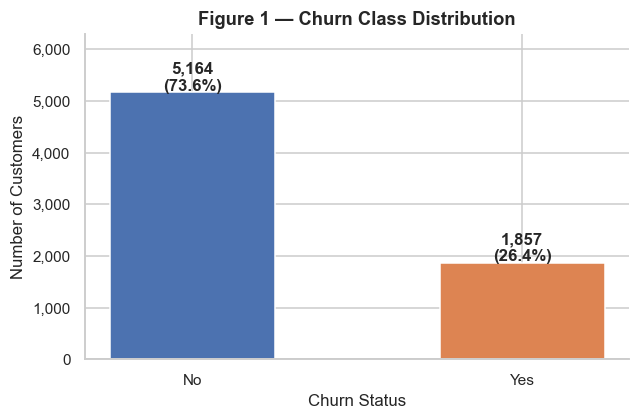

In [10]:
# Add binary numeric target indicator for grouped calculations
df_clean['Churned'] = (df_clean['Churn'] == 'Yes').astype(int)
palette = {'Yes': '#dd8452', 'No': '#4c72b0'}

# ── Figure 1: Churn Class Distribution ───────────────────────────────────────
churn_counts = df_clean['Churn'].value_counts()
churn_pct    = df_clean['Churn'].value_counts(normalize=True) * 100

fig, ax = plt.subplots(figsize=(6, 4))
bars = ax.bar(churn_counts.index, churn_counts.values, color=['#4c72b0', '#dd8452'], width=0.5, edgecolor='white')
for bar, (label, pct) in zip(bars, churn_pct.items()):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 45,
            f'{int(bar.get_height()):,}\n({pct:.1f}%)', ha='center', fontsize=11, fontweight='bold')

ax.set_title('Figure 1 — Churn Class Distribution', fontweight='bold')
ax.set_xlabel('Churn Status')
ax.set_ylabel('Number of Customers')
ax.set_ylim(0, churn_counts.max() * 1.22)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
sns.despine()
plt.tight_layout()
plt.show()

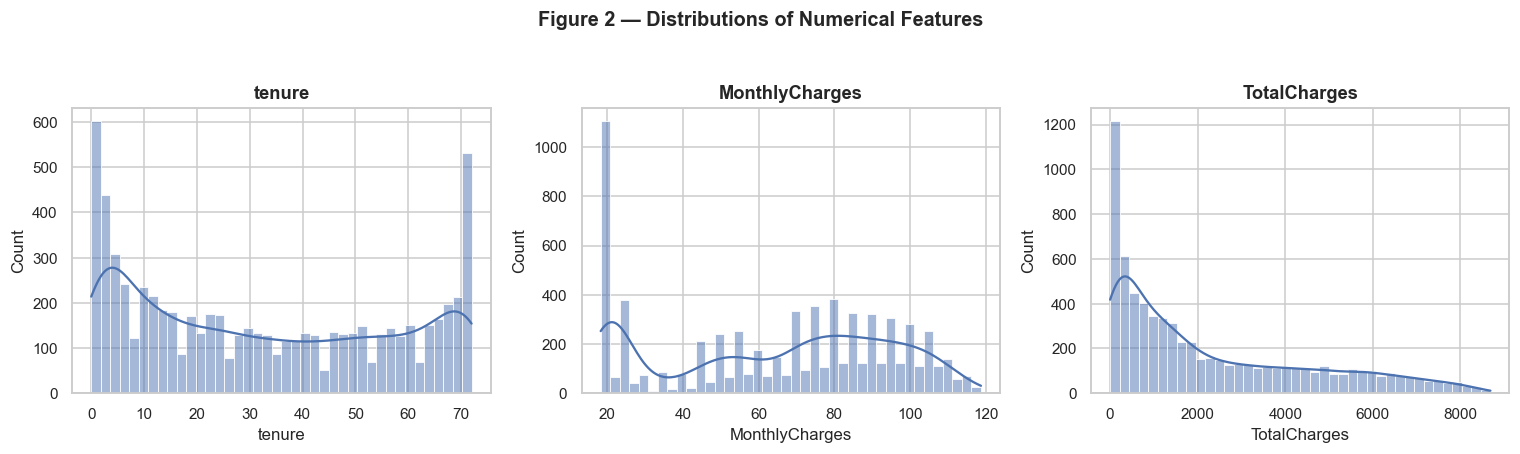

In [11]:
# ── Figure 2: Numerical Feature Distributions ────────────────────────────────
num_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

for ax, col in zip(axes, num_cols):
    sns.histplot(df_clean[col], bins=40, kde=True, ax=ax, color='#4c72b0')
    ax.set_title(col, fontweight='bold')
    ax.set_xlabel(col)
    ax.set_ylabel('Count')

plt.suptitle('Figure 2 — Distributions of Numerical Features', y=1.03, fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

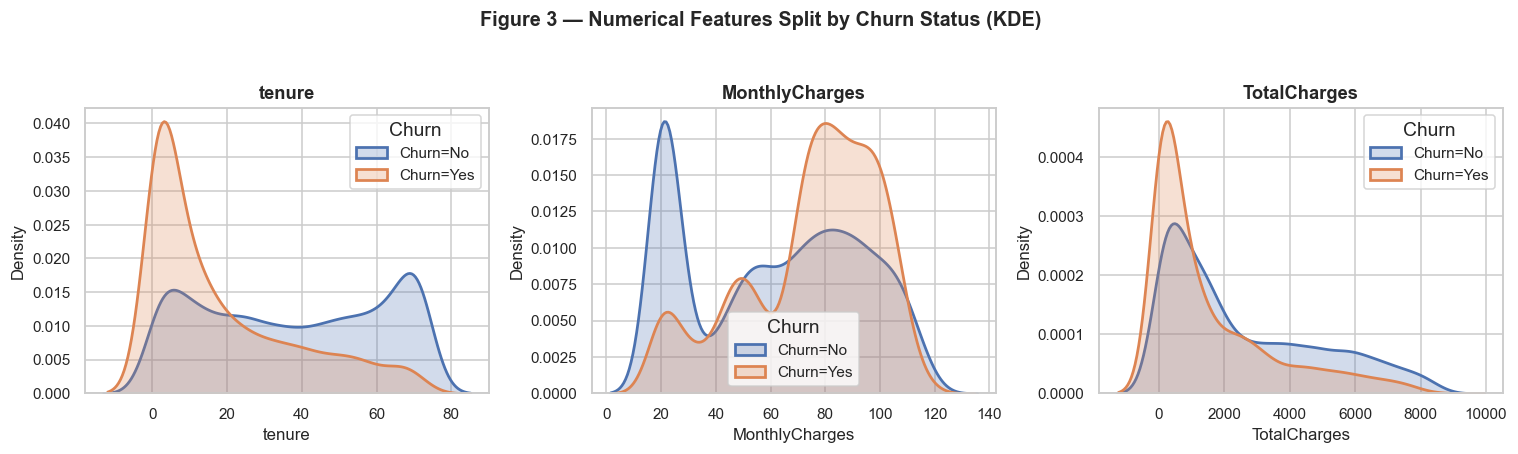

In [12]:
# ── Figure 3: Numerical Features by Churn Status (KDE) ────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

for ax, col in zip(axes, num_cols):
    for churn_val, grp in df_clean.groupby('Churn'):
        sns.kdeplot(grp[col], ax=ax, label=f'Churn={churn_val}',
                    color=palette[churn_val], fill=True, alpha=0.25, linewidth=1.8)
    ax.set_title(col, fontweight='bold')
    ax.set_xlabel(col)
    ax.set_ylabel('Density')
    ax.legend(title='Churn')

plt.suptitle('Figure 3 — Numerical Features Split by Churn Status (KDE)', y=1.03, fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

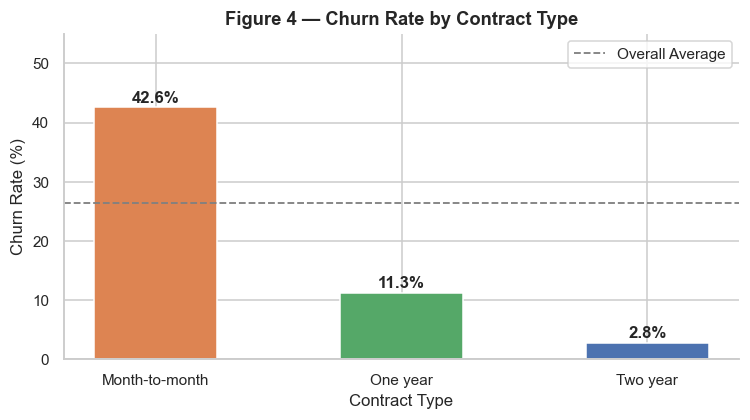

In [13]:
# ── Figure 4: Churn Rate by Contract Type ─────────────────────────────────────
contract_rate = (df_clean.groupby('Contract')['Churned'].mean().mul(100)
                 .sort_values(ascending=False))

fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.bar(contract_rate.index, contract_rate.values,
              color=['#dd8452', '#55a868', '#4c72b0'], edgecolor='white', width=0.5)
for i, (label, val) in enumerate(contract_rate.items()):
    ax.text(i, val + 0.8, f'{val:.1f}%', ha='center', fontsize=11, fontweight='bold')

ax.axhline(y=df_clean['Churned'].mean()*100, color='grey', linestyle='--', linewidth=1.2, label='Overall Average')
ax.set_title('Figure 4 — Churn Rate by Contract Type', fontweight='bold')
ax.set_xlabel('Contract Type')
ax.set_ylabel('Churn Rate (%)')
ax.set_ylim(0, 55)
ax.legend()
sns.despine()
plt.tight_layout()
plt.show()

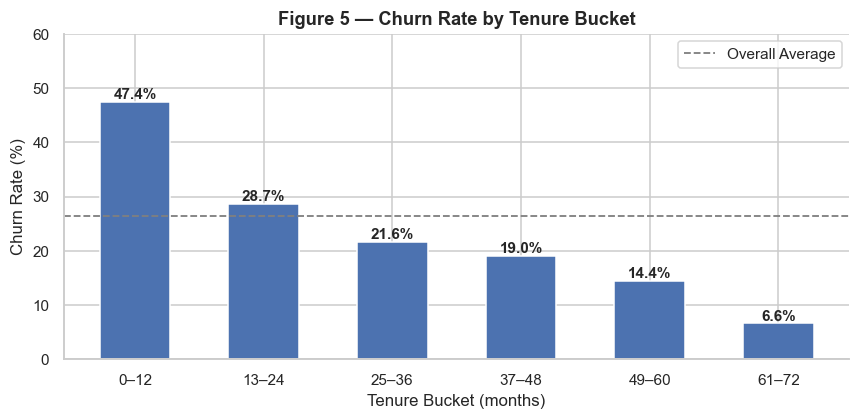

In [14]:
# ── Figure 5: Churn Rate by Tenure Bucket ──────────────────────────────────────
df_t = df_clean.copy()
df_t['tenure_bin'] = pd.cut(df_t['tenure'], bins=[0, 12, 24, 36, 48, 60, 72],
                            labels=['0–12', '13–24', '25–36', '37–48', '49–60', '61–72'],
                            include_lowest=True)
tenure_rate = df_t.groupby('tenure_bin', observed=True)['Churned'].mean().mul(100)

fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.bar(tenure_rate.index, tenure_rate.values, color='#4c72b0', edgecolor='white', width=0.55)
for bar in bars:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.6,
            f'{bar.get_height():.1f}%', ha='center', fontsize=10, fontweight='bold')

ax.axhline(y=df_clean['Churned'].mean()*100, color='grey', linestyle='--', linewidth=1.2, label='Overall Average')
ax.set_title('Figure 5 — Churn Rate by Tenure Bucket', fontweight='bold')
ax.set_xlabel('Tenure Bucket (months)')
ax.set_ylabel('Churn Rate (%)')
ax.set_ylim(0, 60)
ax.legend()
sns.despine()
plt.tight_layout()
plt.show()

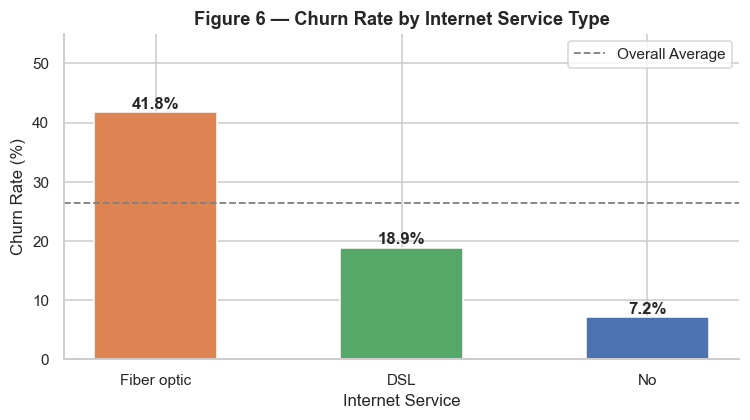

In [15]:
# ── Figure 6: Churn Rate by Internet Service Type ──────────────────────────────
internet_rate = (df_clean.groupby('InternetService')['Churned'].mean().mul(100)
                 .sort_values(ascending=False))

fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.bar(internet_rate.index, internet_rate.values,
              color=['#dd8452', '#55a868', '#4c72b0'], edgecolor='white', width=0.5)
for i, (label, val) in enumerate(internet_rate.items()):
    ax.text(i, val + 0.6, f'{val:.1f}%', ha='center', fontsize=11, fontweight='bold')

ax.axhline(y=df_clean['Churned'].mean()*100, color='grey', linestyle='--', linewidth=1.2, label='Overall Average')
ax.set_title('Figure 6 — Churn Rate by Internet Service Type', fontweight='bold')
ax.set_xlabel('Internet Service')
ax.set_ylabel('Churn Rate (%)')
ax.set_ylim(0, 55)
ax.legend()
sns.despine()
plt.tight_layout()
plt.show()

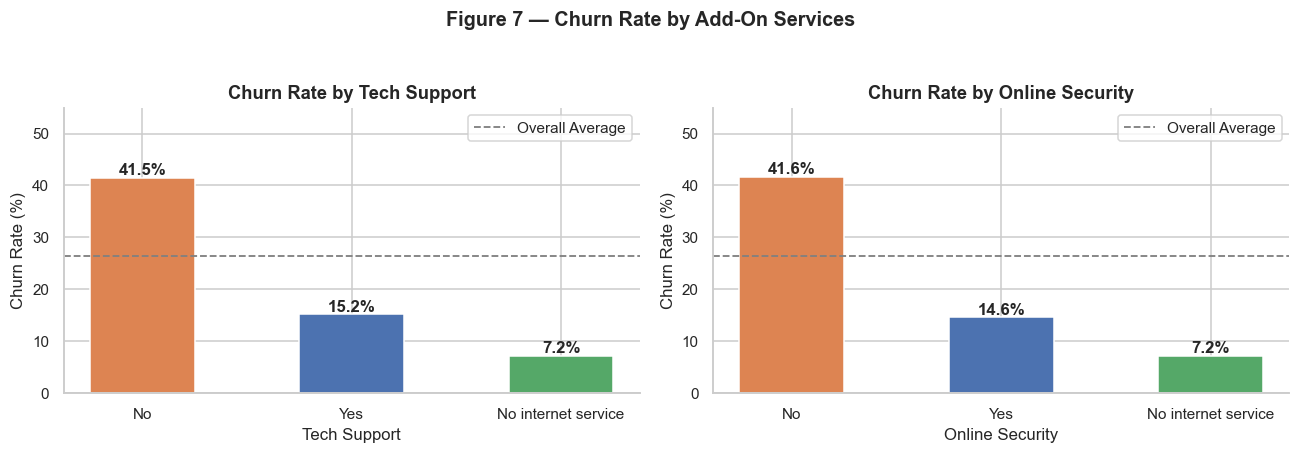

In [16]:
# ── Figure 7: Churn Rate by Add-on Services ───────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
addon_colors = {'Yes': '#4c72b0', 'No': '#dd8452', 'No internet service': '#55a868'}

for ax, col, title in zip(axes, ['TechSupport', 'OnlineSecurity'], ['Tech Support', 'Online Security']):
    rate = df_clean.groupby(col)['Churned'].mean().mul(100).sort_values(ascending=False)
    bar_c = [addon_colors.get(idx, '#999') for idx in rate.index]
    ax.bar(rate.index, rate.values, color=bar_c, edgecolor='white', width=0.5)
    for i, (label, val) in enumerate(rate.items()):
        ax.text(i, val + 0.6, f'{val:.1f}%', ha='center', fontsize=11, fontweight='bold')
    ax.axhline(y=df_clean['Churned'].mean()*100, color='grey', linestyle='--', linewidth=1.2, label='Overall Average')
    ax.set_title(f'Churn Rate by {title}', fontweight='bold')
    ax.set_xlabel(title)
    ax.set_ylabel('Churn Rate (%)')
    ax.set_ylim(0, 55)
    ax.legend()

plt.suptitle('Figure 7 — Churn Rate by Add-On Services', y=1.03, fontsize=13, fontweight='bold')
sns.despine()
plt.tight_layout()
plt.show()

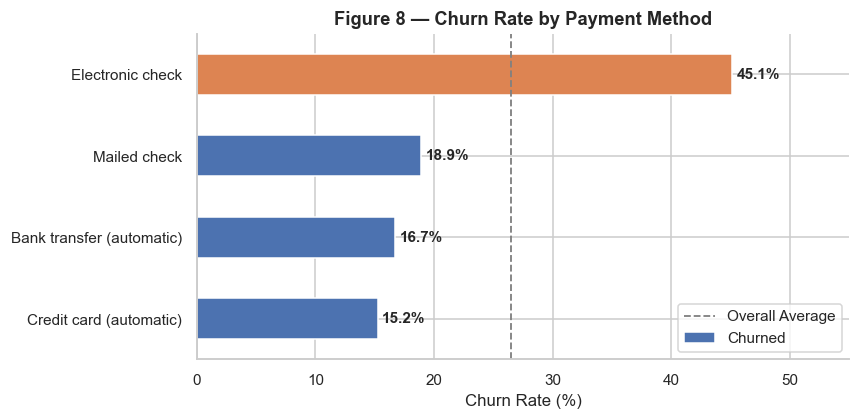

In [17]:
# ── Figure 8: Churn Rate by Payment Method ────────────────────────────────────
pay_rate = df_clean.groupby('PaymentMethod')['Churned'].mean().mul(100).sort_values()

fig, ax = plt.subplots(figsize=(8, 4))
bar_colors = ['#4c72b0' if v < 26.5 else '#dd8452' for v in pay_rate.values]
pay_rate.plot(kind='barh', ax=ax, color=bar_colors, edgecolor='white')

for bar in ax.patches:
    ax.text(bar.get_width() + 0.4, bar.get_y() + bar.get_height()/2,
            f'{bar.get_width():.1f}%', va='center', fontsize=10, fontweight='bold')

ax.axvline(x=df_clean['Churned'].mean()*100, color='grey', linestyle='--', linewidth=1.2, label='Overall Average')
ax.set_title('Figure 8 — Churn Rate by Payment Method', fontweight='bold')
ax.set_xlabel('Churn Rate (%)')
ax.set_ylabel('')
ax.set_xlim(0, 55)
ax.legend()
sns.despine()
plt.tight_layout()
plt.show()

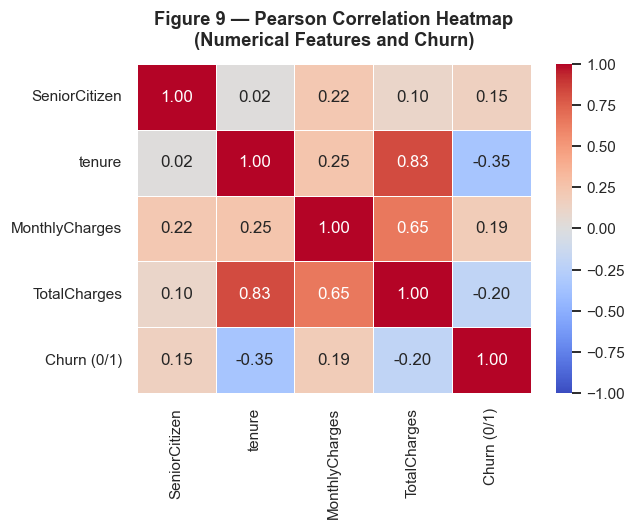

In [18]:
# ── Figure 9: Pearson Correlation Heatmap ──────────────────────────────────────
df_corr = df_clean[['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges', 'Churned']].copy()
df_corr.rename(columns={'Churned': 'Churn (0/1)'}, inplace=True)
corr_matrix = df_corr.corr()

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            vmin=-1, vmax=1, linewidths=0.5, ax=ax, annot_kws={'size': 11})
ax.set_title('Figure 9 — Pearson Correlation Heatmap\n(Numerical Features and Churn)', fontweight='bold', pad=12)
plt.tight_layout()
plt.show()

---
## 7. Feature Engineering and Preprocessing

To prevent data leakage, all scaling and one-hot encoding parameters are fitted strictly on the training partition (`X_train`) and encapsulated inside scikit-learn `Pipeline` and `ColumnTransformer` objects:
- **Target Encoding:** `Churn` is mapped to `1` (Yes) and `0` (No).
- **Features Separation:** 4 numerical features (`SeniorCitizen`, `tenure`, `MonthlyCharges`, `TotalCharges`) and 15 categorical features.
- **Stratified Split:** 80% train (5,616 records), 20% held-out test (1,405 records), preserving class proportions.
- **Leakage-Free Pipelines:** Numerical sub-pipeline (median imputation + `StandardScaler`), categorical sub-pipeline (most-frequent imputation + `OneHotEncoder(handle_unknown='ignore')`).

In [19]:
# Target variable encoding and feature matrix isolation
y = (df_clean['Churn'] == 'Yes').astype(int)
X = df_clean.drop(columns=['Churn', 'Churned'])

numerical_features   = ['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']
categorical_features = [col for col in X.columns if col not in numerical_features]

print(f'Feature matrix X shape: {X.shape[0]:,} rows × {X.shape[1]} features')
print(f'Target vector y shape  : {y.shape[0]:,} records (Churn rate: {y.mean():.4f})')
print(f'Numerical features   ({len(numerical_features)}): {numerical_features}')
print(f'Categorical features ({len(categorical_features)}): {categorical_features}')

Feature matrix X shape: 7,021 rows × 19 features
Target vector y shape  : 7,021 records (Churn rate: 0.2645)
Numerical features   (4): ['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']
Categorical features (15): ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']


In [20]:
# 80/20 Stratified train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=RANDOM_STATE, stratify=y
)

print(f'X_train shape: {X_train.shape} | y_train shape: {y_train.shape} | Churn rate: {y_train.mean():.4f}')
print(f'X_test shape : {X_test.shape}  | y_test shape : {y_test.shape}  | Churn rate: {y_test.mean():.4f}')

X_train shape: (5616, 19) | y_train shape: (5616,) | Churn rate: 0.2644
X_test shape : (1405, 19)  | y_test shape : (1405,)  | Churn rate: 0.2648


In [21]:
# Construct the leakage-free ColumnTransformer
num_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler',  StandardScaler())
])

cat_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', num_pipeline, numerical_features),
        ('cat', cat_pipeline, categorical_features)
    ],
    remainder='drop'
)

# Inspect output dimensionality
sample_transformed = preprocessor.fit_transform(X_train)
ohe_names = preprocessor.named_transformers_['cat'].named_steps['encoder'].get_feature_names_out(categorical_features)
all_feature_names = numerical_features + list(ohe_names)

print(f'Transformed feature vector dimensionality: {sample_transformed.shape[1]} features')
print(f'(4 scaled numerical features + {len(ohe_names)} one-hot encoded dummy indicators)')

Transformed feature vector dimensionality: 45 features
(4 scaled numerical features + 41 one-hot encoded dummy indicators)


---
## 8. Model Training

We train four baseline classification models representing different architectural paradigms:
1. **Logistic Regression:** Linear decision boundary with balanced class weighting.
2. **Decision Tree:** Non-linear rule-based tree (`max_depth=10`, `min_samples_leaf=20`).
3. **Random Forest:** Ensemble of 200 bagging trees with subsample class balancing.
4. **Gradient Boosting:** Sequential boosting ensemble (200 estimators, learning rate 0.1).

Each model is encapsulated in a unified `Pipeline([('preprocessor', preprocessor), ('classifier', clf)])` and fitted on `(X_train, y_train)`.

In [22]:
# Baseline model configurations
model_configs = {
    'Logistic Regression': LogisticRegression(
        C=1.0, max_iter=1000, class_weight='balanced', random_state=RANDOM_STATE, solver='lbfgs'
    ),
    'Decision Tree': DecisionTreeClassifier(
        max_depth=10, min_samples_leaf=20, class_weight='balanced', random_state=RANDOM_STATE
    ),
    'Random Forest': RandomForestClassifier(
        n_estimators=200, min_samples_leaf=5, class_weight='balanced_subsample', random_state=RANDOM_STATE, n_jobs=-1
    ),
    'Gradient Boosting': GradientBoostingClassifier(
        n_estimators=200, learning_rate=0.1, max_depth=4, subsample=0.8, random_state=RANDOM_STATE
    )
}

trained_models = {}
print('Training classification models inside leakage-free pipelines...')

for name, clf in model_configs.items():
    pipe = Pipeline([
        ('preprocessor', copy.deepcopy(preprocessor)),
        ('classifier', clf)
    ])
    pipe.fit(X_train, y_train)
    trained_models[name] = pipe
    train_acc = pipe.score(X_train, y_train)
    print(f'  ✓ {name:<22} trained successfully (Train Accuracy: {train_acc:.4f})')

Training classification models inside leakage-free pipelines...
  ✓ Logistic Regression    trained successfully (Train Accuracy: 0.7514)
  ✓ Decision Tree          trained successfully (Train Accuracy: 0.7901)
  ✓ Random Forest          trained successfully (Train Accuracy: 0.8446)
  ✓ Gradient Boosting      trained successfully (Train Accuracy: 0.8805)


---
## 9. Model Evaluation

We evaluate all four models on the unseen test partition (1,405 records) using metrics suitable for imbalanced classification: Accuracy, Precision, Recall, F1-Score, and ROC-AUC for the churn class (1).

In [23]:
# Compute evaluation metrics on held-out test split
eval_records = []
predictions = {}
probabilities = {}

for name, pipe in trained_models.items():
    y_pred = pipe.predict(X_test)
    y_prob = pipe.predict_proba(X_test)[:, 1]
    predictions[name] = y_pred
    probabilities[name] = y_prob

    eval_records.append({
        'Model':     name,
        'Accuracy':  accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred, zero_division=0),
        'Recall':    recall_score(y_test, y_pred),
        'F1 Score':  f1_score(y_test, y_pred),
        'ROC-AUC':   roc_auc_score(y_test, y_prob)
    })

eval_df = pd.DataFrame(eval_records).set_index('Model')
print('=== Test-Set Evaluation Summary Table (N = 1,405) ===')
display(eval_df.round(4))

=== Test-Set Evaluation Summary Table (N = 1,405) ===


,Accuracy,Precision,Recall,F1 Score,ROC-AUC
Model,,,,,
Logistic Regression,0.7416,0.5079,0.7796,0.6151,0.8398
Decision Tree,0.7274,0.4898,0.7124,0.5805,0.8148
Random Forest,0.7701,0.5520,0.6989,0.6168,0.8372
Gradient Boosting,0.7907,0.6413,0.4758,0.5463,0.8333


In [24]:
# Detailed classification reports
for name in trained_models:
    print('=' * 65)
    print(f'  Classification Report: {name}')
    print('=' * 65)
    print(classification_report(y_test, predictions[name], digits=4, target_names=['No Churn (0)', 'Churn (1)']))

  Classification Report: Logistic Regression
              precision    recall  f1-score   support

No Churn (0)     0.9017    0.7280    0.8056      1033
   Churn (1)     0.5079    0.7796    0.6151       372

    accuracy                         0.7416      1405
   macro avg     0.7048    0.7538    0.7103      1405
weighted avg     0.7974    0.7416    0.7551      1405

  Classification Report: Decision Tree
              precision    recall  f1-score   support

No Churn (0)     0.8762    0.7328    0.7981      1033
   Churn (1)     0.4898    0.7124    0.5805       372

    accuracy                         0.7274      1405
   macro avg     0.6830    0.7226    0.6893      1405
weighted avg     0.7739    0.7274    0.7405      1405

  Classification Report: Random Forest
              precision    recall  f1-score   support

No Churn (0)     0.8801    0.7957    0.8358      1033
   Churn (1)     0.5520    0.6989    0.6168       372

    accuracy                         0.7701      1405
   ma

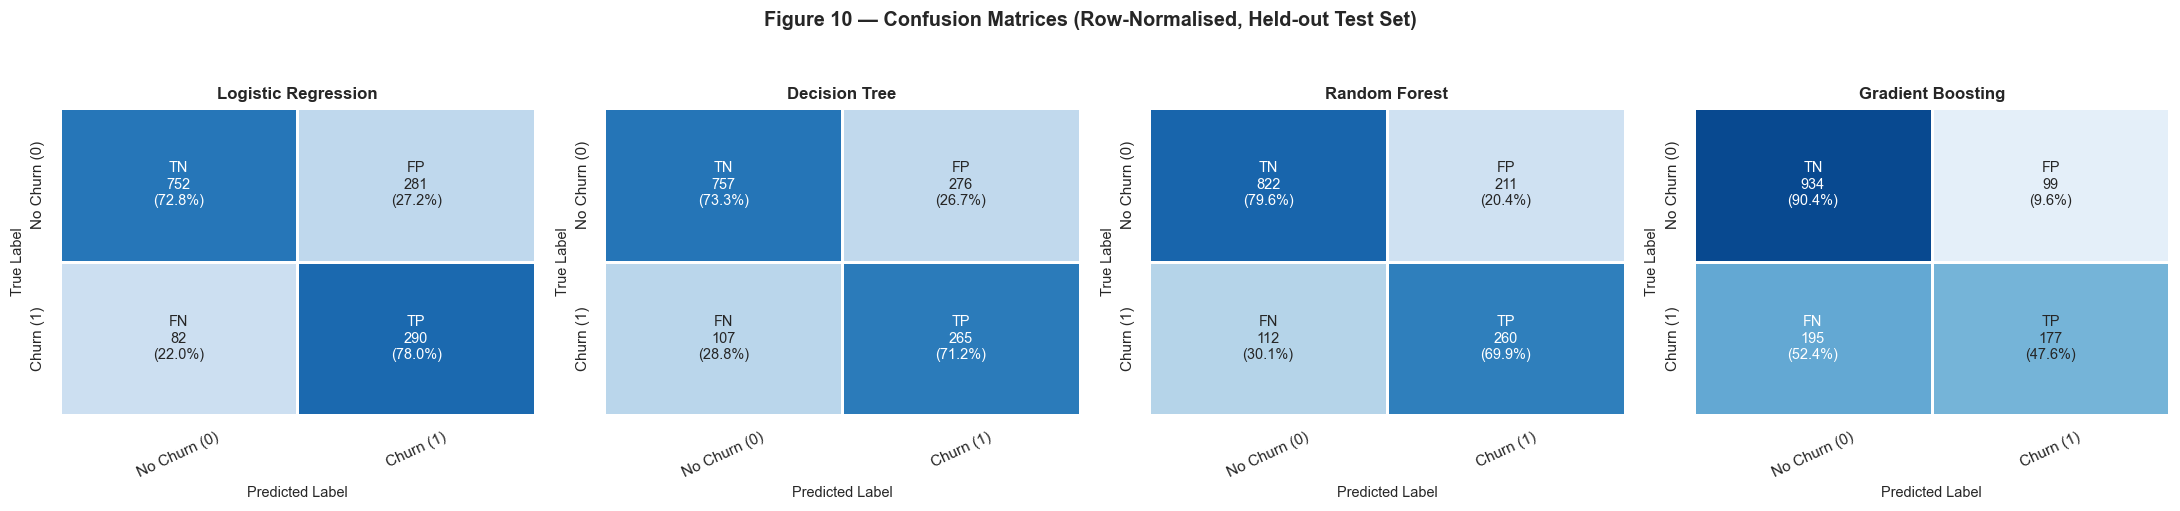

In [25]:
# ── Figure 10: Confusion Matrices ─────────────────────────────────────────────
class_labels = ['No Churn (0)', 'Churn (1)']
fig, axes = plt.subplots(1, 4, figsize=(20, 4.5))

for ax, name in zip(axes, trained_models):
    cm = confusion_matrix(y_test, predictions[name])
    cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
    cell_labels = [['TN', 'FP'], ['FN', 'TP']]
    annot = np.empty_like(cm, dtype=object)
    for r in range(2):
        for c in range(2):
            annot[r, c] = f'{cell_labels[r][c]}\n{cm[r, c]:,}\n({cm_norm[r, c]:.1%})'

    sns.heatmap(cm_norm, ax=ax, annot=annot, fmt='', cmap='Blues', vmin=0, vmax=1,
                linewidths=0.8, linecolor='white', cbar=False,
                xticklabels=class_labels, yticklabels=class_labels, annot_kws={'size': 9.5})
    ax.set_title(name, fontweight='bold', fontsize=11)
    ax.set_xlabel('Predicted Label', fontsize=9.5)
    ax.set_ylabel('True Label', fontsize=9.5)
    ax.tick_params(axis='x', rotation=25)

plt.suptitle('Figure 10 — Confusion Matrices (Row-Normalised, Held-out Test Set)', y=1.03, fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

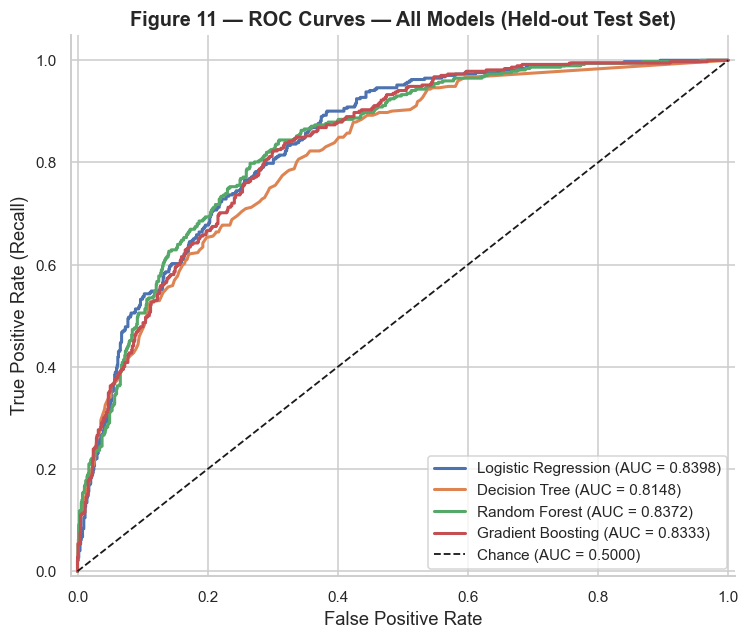

In [26]:
# ── Figure 11: ROC Curves ──────────────────────────────────────────────────────
roc_palette = {'Logistic Regression': '#4c72b0', 'Decision Tree': '#dd8452',
               'Random Forest': '#55a868', 'Gradient Boosting': '#c44e52'}

fig, ax = plt.subplots(figsize=(7, 6))
for name in trained_models:
    fpr, tpr, _ = roc_curve(y_test, probabilities[name])
    auc_val = roc_auc_score(y_test, probabilities[name])
    ax.plot(fpr, tpr, lw=2, color=roc_palette[name], label=f'{name} (AUC = {auc_val:.4f})')

ax.plot([0, 1], [0, 1], 'k--', lw=1.2, label='Chance (AUC = 0.5000)')
ax.set_xlim([-0.01, 1.01])
ax.set_ylim([-0.01, 1.05])
ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate (Recall)', fontsize=12)
ax.set_title('Figure 11 — ROC Curves — All Models (Held-out Test Set)', fontweight='bold', fontsize=13)
ax.legend(loc='lower right', fontsize=10)
sns.despine()
plt.tight_layout()
plt.show()

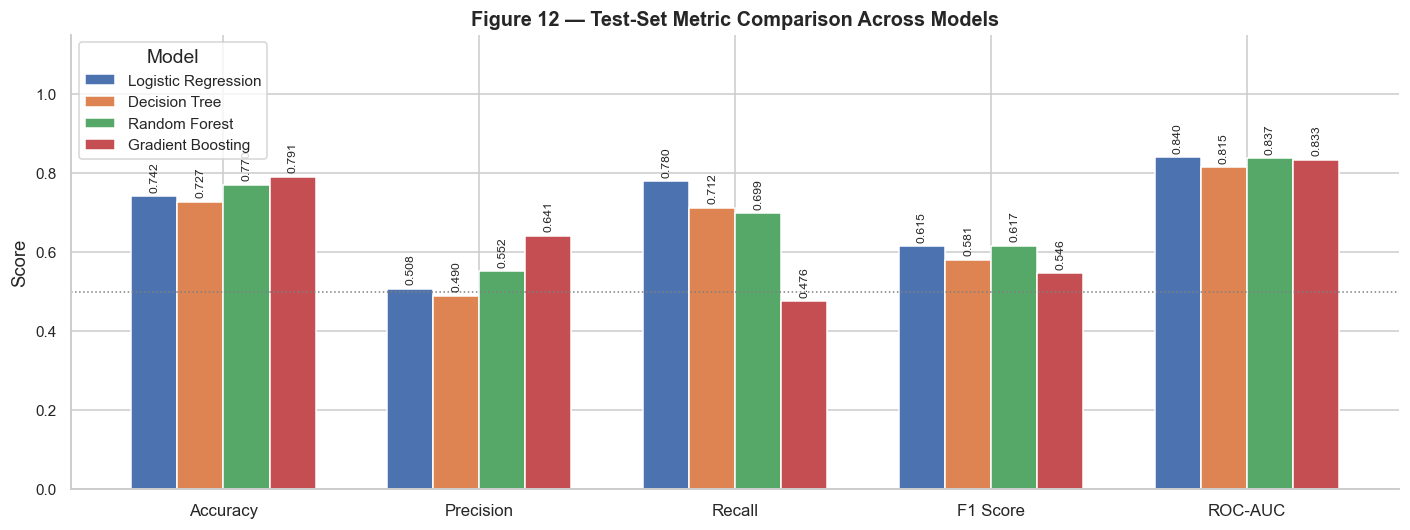

In [27]:
# ── Figure 12: Metric Comparison Bar Chart ────────────────────────────────────
metrics_list = ['Accuracy', 'Precision', 'Recall', 'F1 Score', 'ROC-AUC']
model_names  = list(trained_models.keys())
x_indices    = np.arange(len(metrics_list))
bar_width    = 0.18
colors4      = ['#4c72b0', '#dd8452', '#55a868', '#c44e52']

fig, ax = plt.subplots(figsize=(13, 5))
for i, (name, color) in enumerate(zip(model_names, colors4)):
    offset = x_indices + (i - (len(model_names)-1)/2) * bar_width
    scores = [eval_df.loc[name, m] for m in metrics_list]
    bars = ax.bar(offset, scores, width=bar_width, color=color, edgecolor='white', label=name)
    for bar, val in zip(bars, scores):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                f'{val:.3f}', ha='center', va='bottom', fontsize=8, rotation=90)

ax.set_xticks(x_indices)
ax.set_xticklabels(metrics_list, fontsize=11)
ax.set_ylabel('Score', fontsize=12)
ax.set_ylim(0, 1.15)
ax.axhline(y=0.5, color='grey', linestyle=':', linewidth=1)
ax.set_title('Figure 12 — Test-Set Metric Comparison Across Models', fontweight='bold', fontsize=13)
ax.legend(title='Model', loc='upper left')
sns.despine()
plt.tight_layout()
plt.show()

---
## 10. Model Interpretation

To ensure transparency and business interpretability, we examine feature relationships using signed coefficients for Logistic Regression and impurity-based (Gini) importances for Random Forest and Gradient Boosting. All patterns reflect statistical associations in historical training data.

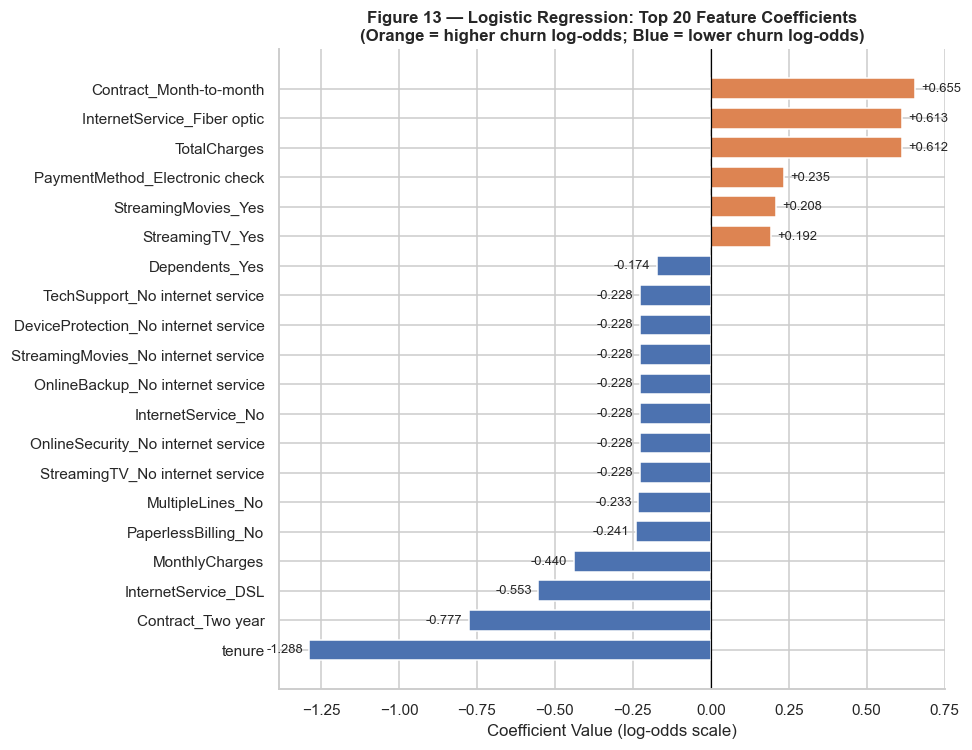

In [28]:
# ── Figure 13: Logistic Regression Feature Coefficients ───────────────────────
lr_clf = trained_models['Logistic Regression'].named_steps['classifier']
lr_coef = lr_clf.coef_[0]

coef_df = pd.DataFrame({'Feature': all_feature_names, 'Coefficient': lr_coef, 'Abs': np.abs(lr_coef)})
top20_coef = coef_df.sort_values('Abs', ascending=False).head(20).sort_values('Coefficient')

colors_lr = ['#dd8452' if v > 0 else '#4c72b0' for v in top20_coef['Coefficient']]

fig, ax = plt.subplots(figsize=(9, 7))
ax.barh(top20_coef['Feature'], top20_coef['Coefficient'], color=colors_lr, edgecolor='white', height=0.7)
ax.axvline(x=0, color='black', linewidth=0.8)
ax.set_xlabel('Coefficient Value (log-odds scale)', fontsize=11)
ax.set_title('Figure 13 — Logistic Regression: Top 20 Feature Coefficients\n(Orange = higher churn log-odds; Blue = lower churn log-odds)',
             fontweight='bold', fontsize=11)

for bar in ax.patches:
    w = bar.get_width()
    ax.text(w + (0.02 if w >= 0 else -0.02), bar.get_y() + bar.get_height()/2,
            f'{w:+.3f}', va='center', ha='left' if w >= 0 else 'right', fontsize=8.5)

sns.despine()
plt.tight_layout()
plt.show()

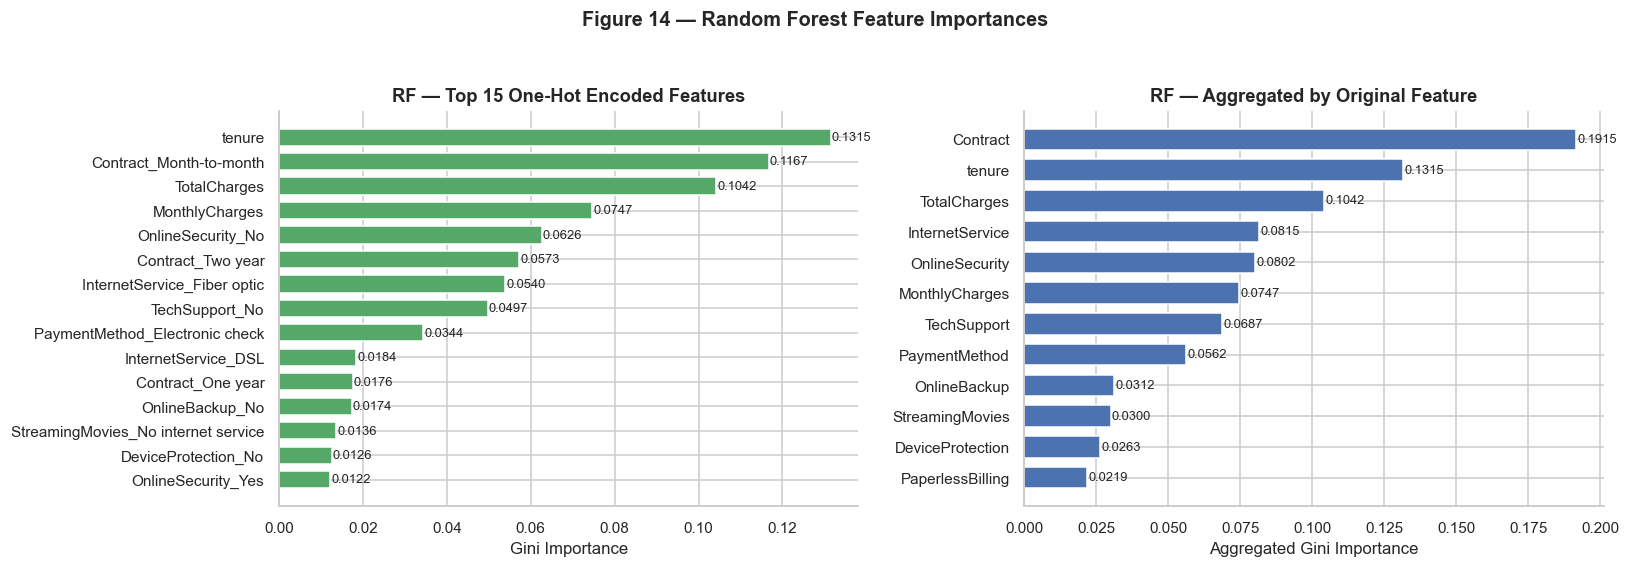

In [29]:
# Helper function to aggregate one-hot encoded feature importances back to original features
def aggregate_importance(imp_df, num_f, cat_f):
    agg = {}
    for f in num_f:
        agg[f] = imp_df.loc[imp_df['Feature'] == f, 'Importance'].sum()
    for f in cat_f:
        agg[f] = imp_df.loc[imp_df['Feature'].str.startswith(f + '_'), 'Importance'].sum()
    return pd.Series(agg).sort_values(ascending=False)

# ── Figure 14: Random Forest Feature Importances ──────────────────────────────
rf_clf = trained_models['Random Forest'].named_steps['classifier']
rf_imp_df = pd.DataFrame({'Feature': all_feature_names, 'Importance': rf_clf.feature_importances_})
rf_top15 = rf_imp_df.nlargest(15, 'Importance').sort_values('Importance')
rf_agg   = aggregate_importance(rf_imp_df, numerical_features, categorical_features).sort_values().tail(12)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
axes[0].barh(rf_top15['Feature'], rf_top15['Importance'], color='#55a868', edgecolor='white', height=0.7)
for bar in axes[0].patches:
    axes[0].text(bar.get_width() + 0.0002, bar.get_y() + bar.get_height()/2,
                 f'{bar.get_width():.4f}', va='center', fontsize=8.5)
axes[0].set_xlabel('Gini Importance')
axes[0].set_title('RF — Top 15 One-Hot Encoded Features', fontweight='bold')

axes[1].barh(rf_agg.index, rf_agg.values, color='#4c72b0', edgecolor='white', height=0.7)
for bar in axes[1].patches:
    axes[1].text(bar.get_width() + 0.0005, bar.get_y() + bar.get_height()/2,
                 f'{bar.get_width():.4f}', va='center', fontsize=8.5)
axes[1].set_xlabel('Aggregated Gini Importance')
axes[1].set_title('RF — Aggregated by Original Feature', fontweight='bold')

plt.suptitle('Figure 14 — Random Forest Feature Importances', y=1.03, fontsize=13, fontweight='bold')
sns.despine()
plt.tight_layout()
plt.show()

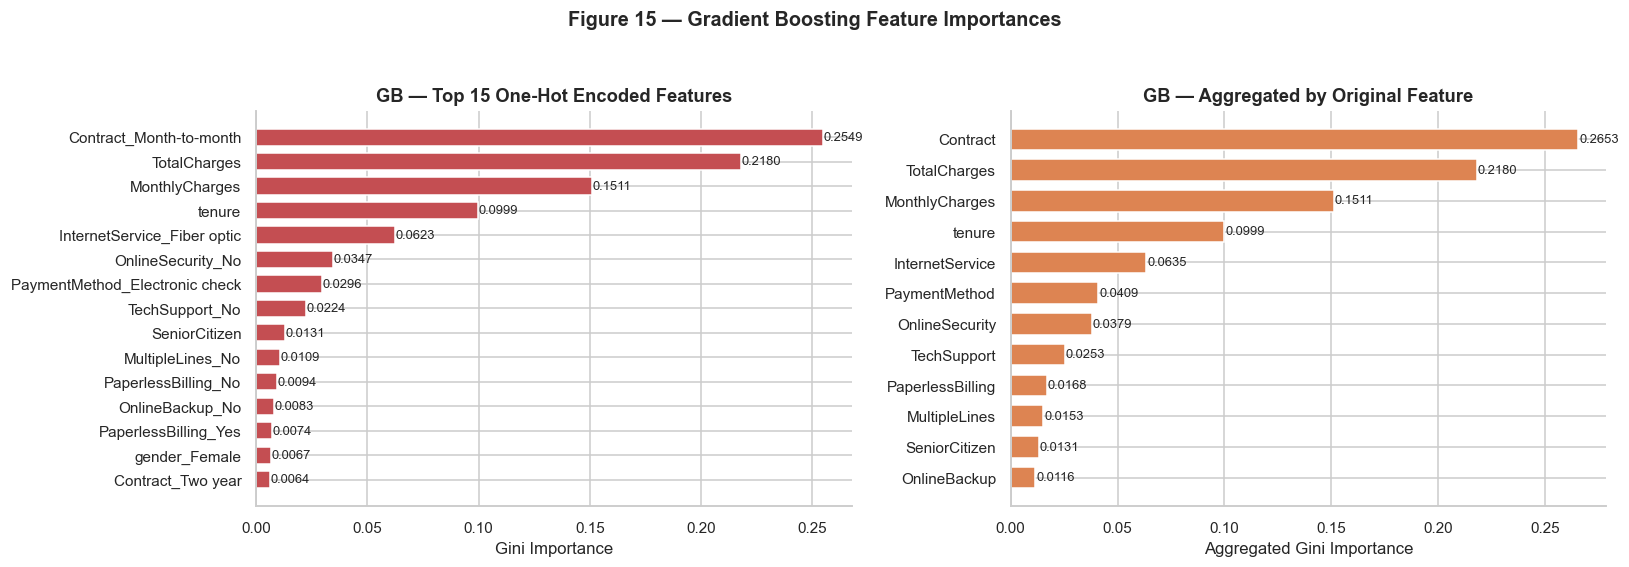

In [30]:
# ── Figure 15: Gradient Boosting Feature Importances ──────────────────────────
gb_clf = trained_models['Gradient Boosting'].named_steps['classifier']
gb_imp_df = pd.DataFrame({'Feature': all_feature_names, 'Importance': gb_clf.feature_importances_})
gb_top15 = gb_imp_df.nlargest(15, 'Importance').sort_values('Importance')
gb_agg   = aggregate_importance(gb_imp_df, numerical_features, categorical_features).sort_values().tail(12)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
axes[0].barh(gb_top15['Feature'], gb_top15['Importance'], color='#c44e52', edgecolor='white', height=0.7)
for bar in axes[0].patches:
    axes[0].text(bar.get_width() + 0.0002, bar.get_y() + bar.get_height()/2,
                 f'{bar.get_width():.4f}', va='center', fontsize=8.5)
axes[0].set_xlabel('Gini Importance')
axes[0].set_title('GB — Top 15 One-Hot Encoded Features', fontweight='bold')

axes[1].barh(gb_agg.index, gb_agg.values, color='#dd8452', edgecolor='white', height=0.7)
for bar in axes[1].patches:
    axes[1].text(bar.get_width() + 0.0005, bar.get_y() + bar.get_height()/2,
                 f'{bar.get_width():.4f}', va='center', fontsize=8.5)
axes[1].set_xlabel('Aggregated Gini Importance')
axes[1].set_title('GB — Aggregated by Original Feature', fontweight='bold')

plt.suptitle('Figure 15 — Gradient Boosting Feature Importances', y=1.03, fontsize=13, fontweight='bold')
sns.despine()
plt.tight_layout()
plt.show()

---
## 11. Final Model Selection

We select the final model using an evidence-based multi-criteria framework:
- **Primary Metric (F1-Score):** The harmonic mean of Precision and Recall on the minority churn class.
- **Recall Requirement:** The model must catch a substantial portion of actual churners (avoiding costly False Negatives).
- **Precision Requirement:** Predictions must maintain acceptable precision to prevent excessive False Positives (avoiding budget waste on retention offers).
- **Discrimination (ROC-AUC):** High ranking ability across decision thresholds.

### Selection Matrix

| Model | Accuracy | Precision | Recall | F1-Score | ROC-AUC | Profile Assessment |
|---|---|---|---|---|---|---|
| **Random Forest ★** | **0.7701** | **0.5520** | **0.6989** | **0.6168** | **0.8372** | **Selected:** Highest F1-Score; best balanced Recall/Precision trade-off |
| Logistic Regression | 0.7416 | 0.5079 | **0.7796** | 0.6151 | **0.8398** | High Recall, but ~49% false alarms (lower precision) |
| Decision Tree | 0.7274 | 0.4898 | 0.7124 | 0.5805 | 0.8148 | Lowest overall precision and F1 among all baselines |
| Gradient Boosting | **0.7907** | **0.6413** | 0.4758 | 0.5463 | 0.8333 | High Precision, but misses over 52% of actual churners |

**Selection Decision:**  
**Random Forest** is selected as the final operational model. It achieves the highest F1-Score (0.6168), captures ~70% of actual churners (Recall = 0.6989), maintains superior Precision (0.5520) compared to Logistic Regression, and yields strong discrimination (ROC-AUC = 0.8372).  
*Disclaimer:* This model is selected for the specific trade-offs of this telecommunications dataset. It is not claimed to be universally optimal across all domains.

In [31]:
# Verification of selected final model metrics
FINAL_MODEL_NAME = 'Random Forest'
final_pipeline   = trained_models[FINAL_MODEL_NAME]

rf_pred = final_pipeline.predict(X_test)
rf_prob = final_pipeline.predict_proba(X_test)[:, 1]

print(f'Selected Model: {FINAL_MODEL_NAME}')
print(f'  Accuracy : {accuracy_score(y_test, rf_pred):.4f} (Expected: 0.7701)')
print(f'  Precision: {precision_score(y_test, rf_pred):.4f} (Expected: 0.5520)')
print(f'  Recall   : {recall_score(y_test, rf_pred):.4f} (Expected: 0.6989)')
print(f'  F1-Score : {f1_score(y_test, rf_pred):.4f} (Expected: 0.6168)')
print(f'  ROC-AUC  : {roc_auc_score(y_test, rf_prob):.4f} (Expected: 0.8372)')

Selected Model: Random Forest
  Accuracy : 0.7701 (Expected: 0.7701)
  Precision: 0.5520 (Expected: 0.5520)
  Recall   : 0.6989 (Expected: 0.6989)
  F1-Score : 0.6168 (Expected: 0.6168)
  ROC-AUC  : 0.8372 (Expected: 0.8372)


---
## 12. Save Final Model

We persist the selected Random Forest pipeline to `models/final_churn_model.joblib`. Because the object is a complete scikit-learn `Pipeline`, it encapsulates both the fitted `ColumnTransformer` preprocessor and the fitted `RandomForestClassifier`. New customer records can be passed directly to `model.predict()` without manual scaling or dummy variable creation.

In [32]:
# Save the complete pipeline to models/final_churn_model.joblib
os.makedirs(MODELS_DIR, exist_ok=True)
joblib.dump(final_pipeline, FINAL_MODEL_PATH)

size_kb = os.path.getsize(FINAL_MODEL_PATH) / 1024
print(f'Final pipeline saved to: {FINAL_MODEL_PATH}')
print(f'Serialized file size   : {size_kb:.1f} KB')

# Reload and confirm prediction consistency
reloaded_model = joblib.load(FINAL_MODEL_PATH)
predictions_match = np.array_equal(final_pipeline.predict(X_test), reloaded_model.predict(X_test))
print(f'Reload verification    : Predictions match exactly = {predictions_match}')
print('\nPipeline structure:')
for step_name, step_obj in reloaded_model.steps:
    print(f'  - {step_name:<14}: {step_obj.__class__.__name__}')

Final pipeline saved to: c:\Users\Subham\OneDrive\Documents\Desktop\Customer_Churn_Project\models\final_churn_model.joblib
Serialized file size   : 10988.5 KB
Reload verification    : Predictions match exactly = True

Pipeline structure:
  - preprocessor  : ColumnTransformer
  - classifier    : RandomForestClassifier


---
## 13. Final Prediction / Inference

To demonstrate practical deployment, we construct five hypothetical customer records (`C001` through `C005`) spanning low, intermediate, and high risk profiles. We apply the loaded model and assign each customer to an illustrative risk tier.

In [33]:
# Define hypothetical customer profiles
new_customers = pd.DataFrame({
    'gender':           ['Female', 'Male',          'Female',       'Male',          'Female'],
    'SeniorCitizen':    [0,        0,               0,              1,               0],
    'Partner':          ['Yes',    'No',            'Yes',          'No',            'Yes'],
    'Dependents':       ['Yes',    'No',            'No',           'No',            'No'],
    'tenure':           [58,       2,               24,             6,               65],
    'PhoneService':     ['Yes',    'Yes',           'Yes',          'Yes',           'No'],
    'MultipleLines':    ['No',     'No',            'Yes',          'Yes',           'No phone service'],
    'InternetService':  ['DSL',    'Fiber optic',   'DSL',          'Fiber optic',   'No'],
    'OnlineSecurity':   ['Yes',    'No',            'Yes',          'No',            'No internet service'],
    'OnlineBackup':     ['Yes',    'No',            'No',           'No',            'No internet service'],
    'DeviceProtection': ['Yes',    'No',            'Yes',          'No',            'No internet service'],
    'TechSupport':      ['Yes',    'No',            'No',           'No',            'No internet service'],
    'StreamingTV':      ['No',     'Yes',           'No',           'Yes',           'No internet service'],
    'StreamingMovies':  ['No',     'Yes',           'Yes',          'Yes',           'No internet service'],
    'Contract':         ['Two year', 'Month-to-month', 'One year',  'Month-to-month', 'Two year'],
    'PaperlessBilling': ['No',     'Yes',           'No',           'Yes',           'No'],
    'PaymentMethod':    ['Bank transfer (automatic)', 'Electronic check',
                         'Mailed check', 'Electronic check',
                         'Credit card (automatic)'],
    'MonthlyCharges':   [55.90,    89.10,           59.65,          99.45,           20.05],
    'TotalCharges':     [3242.20,  178.20,          1431.60,        596.70,          1303.25],
}, index=['C001', 'C002', 'C003', 'C004', 'C005'])
new_customers.index.name = 'CustomerID'

display(new_customers.T)

CustomerID,C001,C002,C003,C004,C005
gender,Female,Male,Female,Male,Female
SeniorCitizen,0,0,0,1,0
Partner,Yes,No,Yes,No,Yes
Dependents,Yes,No,No,No,No
tenure,58,2,24,6,65
PhoneService,Yes,Yes,Yes,Yes,No
MultipleLines,No,No,Yes,Yes,No phone service
InternetService,DSL,Fiber optic,DSL,Fiber optic,No
OnlineSecurity,Yes,No,Yes,No,No internet service
OnlineBackup,Yes,No,No,No,No internet service


In [34]:
# Run inference with the saved model
loaded_pipeline = joblib.load(FINAL_MODEL_PATH)
infer_preds = loaded_pipeline.predict(new_customers)
infer_probs = loaded_pipeline.predict_proba(new_customers)[:, 1]

# Illustrative risk-tier categorisation
def assign_risk_tier(prob):
    if prob < 0.30:
        return 'Lower predicted churn probability'
    elif prob <= 0.60:
        return 'Intermediate predicted churn probability'
    else:
        return 'Higher predicted churn probability'

inference_results = pd.DataFrame({
    'Constructed Profile': ['Lower risk', 'Higher risk', 'Intermediate', 'Higher risk', 'Lower risk'],
    'Predicted Class':     ['Churn' if p == 1 else 'No Churn' for p in infer_preds],
    'Churn Probability':   np.round(infer_probs, 4),
    'Risk Tier':           [assign_risk_tier(p) for p in infer_probs]
}, index=new_customers.index)

print('=== Inference Results Table ===')
display(inference_results)

=== Inference Results Table ===


,Constructed Profile,Predicted Class,Churn Probability,Risk Tier
CustomerID,,,,
C001,Lower risk,No Churn,0.1058,Lower predicted churn probability
C002,Higher risk,Churn,0.8853,Higher predicted churn probability
C003,Intermediate,No Churn,0.1095,Lower predicted churn probability
C004,Higher risk,Churn,0.9389,Higher predicted churn probability
C005,Lower risk,No Churn,0.0140,Lower predicted churn probability


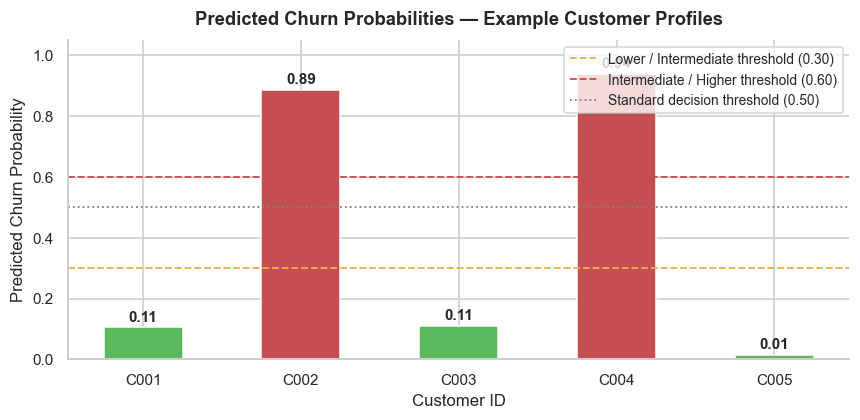

Inference pipeline verification: ALL CHECKS PASSED ✓


In [35]:
# Visualise predicted churn probabilities across example profiles
bar_colors = ['#c44e52' if p > 0.60 else '#f0ad4e' if p >= 0.30 else '#5cb85c' for p in infer_probs]

fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.bar(new_customers.index, infer_probs, color=bar_colors, edgecolor='white', width=0.5)

for bar, prob in zip(bars, infer_probs):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
            f'{prob:.2f}', ha='center', fontsize=10, fontweight='bold')

ax.axhline(y=0.30, color='#f0ad4e', linestyle='--', linewidth=1.2, label='Lower / Intermediate threshold (0.30)')
ax.axhline(y=0.60, color='#c44e52', linestyle='--', linewidth=1.2, label='Intermediate / Higher threshold (0.60)')
ax.axhline(y=0.50, color='grey',    linestyle=':',  linewidth=1.2, label='Standard decision threshold (0.50)')

ax.set_title('Predicted Churn Probabilities — Example Customer Profiles', fontweight='bold', pad=10)
ax.set_xlabel('Customer ID')
ax.set_ylabel('Predicted Churn Probability')
ax.set_ylim(0, 1.05)
ax.legend(loc='upper right', fontsize=9)
sns.despine()
plt.tight_layout()
plt.show()

# Verification assertions
assert len(infer_preds) == len(new_customers)
assert np.all((infer_probs >= 0.0) & (infer_probs <= 1.0))
print('Inference pipeline verification: ALL CHECKS PASSED ✓')

---
## 14. Conclusion

### Summary of Workflow and Findings
This project successfully implemented an end-to-end, reproducible machine learning workflow for customer churn prediction:
- **Data Quality:** Coerced `TotalCharges` strings to float, correctly resolved 11 tenure-0 blank records to `0.0`, and eliminated `customerID` along with 22 duplicate rows, yielding 7,021 clean customer records.
- **Exploratory Analysis:** Established that contract duration, tenure, internet service type (notably fiber optic), absent tech support add-ons, and payment methods are strongly associated with customer churn.
- **Modeling & Evaluation:** Built leakage-free scikit-learn pipelines for four baseline algorithms. Evaluated on a held-out test split of 1,405 customers, **Random Forest** proved to be the most balanced model, capturing ~70% of actual churners with the highest F1-Score (0.6168), competitive ROC-AUC (0.8372), and superior Precision (0.5520) relative to high-recall alternatives.
- **Inference Demonstration:** Packaged the fitted preprocessor and classifier into a single `joblib` pipeline, demonstrating portable inference on unseen records.

### Limitations
1. **Single Historical Snapshot:** Trained on a historical dataset from one telecom provider; results may not generalize across differing market contexts without recalibration.
2. **Untuned Baselines:** All models utilized reasonable baseline configurations; systematic hyperparameter tuning (e.g., `GridSearchCV`) and cost-sensitive threshold tuning were not applied.
3. **Statistical Associations (Non-Causal):** Predictions reflect correlational patterns in training records and should not be interpreted as causal relationships.

---
## 15. References

1. **Telco Customer Churn Dataset:** IBM Watson Analytics Sample Data. Available on Kaggle: https://www.kaggle.com/datasets/blastchar/telco-customer-churn
2. **scikit-learn:** Pedregosa, F. et al. (2011). *Scikit-learn: Machine Learning in Python*. Journal of Machine Learning Research, 12, 2825–2830. https://scikit-learn.org/stable/
3. **pandas:** The Pandas Development Team. (2023). *pandas-dev/pandas: Pandas*. https://pandas.pydata.org/docs/
4. **NumPy:** Harris, C. R. et al. (2020). *Array programming with NumPy*. Nature, 585, 357–362. https://numpy.org/doc/
5. **Matplotlib:** Hunter, J. D. (2007). *Matplotlib: A 2D Graphics Environment*. Computing in Science & Engineering, 9(3), 90–95. https://matplotlib.org/stable/
6. **seaborn:** Waskom, M. L. (2021). *seaborn: statistical data visualization*. Journal of Open Source Software, 6(60), 3021. https://seaborn.pydata.org/
7. **joblib:** Joblib Development Team. *Lightweight pipelining with Python*. https://joblib.readthedocs.io/
8. **Jupyter Notebook:** Kluyver, T. et al. (2016). *Jupyter Notebooks — a publishing format for reproducible computational workflows*. Positioning and Power in Academic Publishing, 87–90. https://jupyter-notebook.readthedocs.io/
9. **Reference Notebook:** Rahman, F. (2019). *"Telco Customer Churn – Logistic Regression"*. Kaggle. Reference consulted during project development. Available at: https://www.kaggle.com/code/farazrahman/telco-customer-churn-logisticregression